In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# File path base
import os
os.chdir(r"C:\Users\mmand\Desktop\supply-chain-delay-predictor")
PATH = "data/raw/Brazilian E-Comm/"
# Load the key files
orders = pd.read_csv(PATH + "olist_orders_dataset.csv",
    parse_dates=[
        'order_purchase_timestamp',
        'order_estimated_delivery_date',
        'order_delivered_customer_date'
    ])

items    = pd.read_csv(PATH + "olist_order_items_dataset.csv")
sellers  = pd.read_csv(PATH + "olist_sellers_dataset.csv")
products = pd.read_csv(PATH + "olist_products_dataset.csv")
geo      = pd.read_csv(PATH + "olist_geolocation_dataset.csv")

print("✅ All files loaded!")
print(f"   Orders:   {orders.shape[0]:,} rows")
print(f"   Items:    {items.shape[0]:,} rows")
print(f"   Sellers:  {sellers.shape[0]:,} rows")
print(f"   Products: {products.shape[0]:,} rows")

✅ All files loaded!
   Orders:   99,441 rows
   Items:    112,650 rows
   Sellers:  3,095 rows
   Products: 32,951 rows


In [6]:
# Keep only delivered orders (we need actual delivery date)
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# Drop rows where delivery date is missing
orders_clean = orders_clean.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# Create target variable: 1 = delayed, 0 = on time
orders_clean['is_delayed'] = (
    orders_clean['order_delivered_customer_date'] >
    orders_clean['order_estimated_delivery_date']
).astype(int)

# How many days early or late?
orders_clean['delay_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_estimated_delivery_date']
).dt.days

total = len(orders_clean)
delayed = orders_clean['is_delayed'].sum()
pct = round((delayed / total) * 100, 1)

print(f"✅ Clean orders: {total:,}")
print(f"   Delayed:      {delayed:,} ({pct}%)")
print(f"   On time:      {total - delayed:,} ({round(100 - pct, 1)}%)")

✅ Clean orders: 96,470
   Delayed:      7,826 (8.1%)
   On time:      88,644 (91.9%)


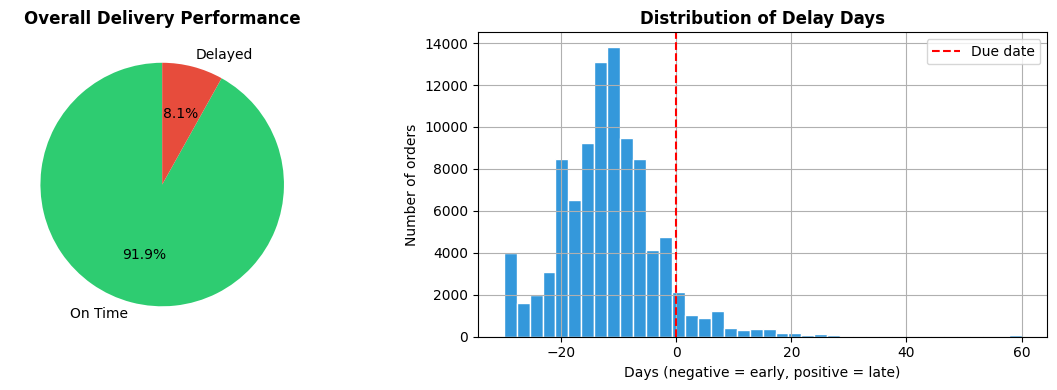

✅ Chart saved to reports/


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Pie chart of delay rate
axes[0].pie(
    [total - delayed, delayed],
    labels=['On Time', 'Delayed'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Overall Delivery Performance', fontweight='bold')

# Chart 2: Distribution of delay days
orders_clean['delay_days'].clip(-30, 60).hist(
    bins=40, ax=axes[1], color='#3498db', edgecolor='white'
)
axes[1].axvline(0, color='red', linestyle='--', label='Due date')
axes[1].set_title('Distribution of Delay Days', fontweight='bold')
axes[1].set_xlabel('Days (negative = early, positive = late)')
axes[1].set_ylabel('Number of orders')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/chart_01_delay_overview.png', dpi=150)
plt.show()
print("✅ Chart saved to reports/")